### Librerías a utilizar
---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Importación de datos
---

In [2]:
df = pd.read_csv('../data/raw/synthetic_coffee_health_10000.csv')
df.head()

,ID,Age,Gender,Country,Coffee_Intake,Caffeine_mg,Sleep_Hours,Sleep_Quality,BMI,Heart_Rate,Stress_Level,Physical_Activity_Hours,Health_Issues,Occupation,Smoking,Alcohol_Consumption
0,1,40,Male,Germany,3.5,328.1,7.5,Good,24.9,78,Low,14.5,NaN,Other,0,0
1,2,33,Male,Germany,1.0,94.1,6.2,Good,20.0,67,Low,11.0,NaN,Service,0,0
2,3,42,Male,Brazil,5.3,503.7,5.9,Fair,22.7,59,Medium,11.2,Mild,Office,0,0
3,4,53,Male,Germany,2.6,249.2,7.3,Good,24.7,71,Low,6.6,Mild,Other,0,0
4,5,32,Female,Spain,3.1,298.0,5.3,Fair,24.1,76,Medium,8.5,Mild,Student,0,1


### Visualización de tipos de datos
---

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       10000 non-null  int64  
 1   Age                      10000 non-null  int64  
 2   Gender                   10000 non-null  object 
 3   Country                  10000 non-null  object 
 4   Coffee_Intake            10000 non-null  float64
 5   Caffeine_mg              10000 non-null  float64
 6   Sleep_Hours              10000 non-null  float64
 7   Sleep_Quality            10000 non-null  object 
 8   BMI                      10000 non-null  float64
 9   Heart_Rate               10000 non-null  int64  
 10  Stress_Level             10000 non-null  object 
 11  Physical_Activity_Hours  10000 non-null  float64
 12  Health_Issues            4059 non-null   object 
 13  Occupation               10000 non-null  object 
 14  Smoking                

Como podemos ver el dataset contiene 16 variables:

0. *ID*: Id del participante, variable tipo entero.
1. *Age*: Edad del participante, variable tipo entero.
2. *Gender*: Género del participante, variable categórica.
3. *Country*: País de residencia (20 países), variable categórica.
4. *Coffee_Intake*: Consumo diario de café en tazas (0-10), variable tipo flotante.
5. *Caffeine_mg*: Consumo estimado de caféina diaria (1  taza ≈ 95 mg), variable tipo flotante.
6. *Sleep_Hours*: Promedio de horas de sueño por noche (3-10), variable tipo flotante.
7. *Sleep_Quality*: Calidad de sueño, puede ser mala, regular, buena, excelente, variable categórica.
8. *BMI*: Índice de Masa Corporal (15-40), variable tipo flotante.
9. *Heart_Rate*: Frecuencia cardiaca en reposo (50–110 bpm), variable tipo entero.
10. *Stress_Level*: Nivel de estrés basado en horas de sueño y estilo de vida, puede ser bajo, medio y alto, variable categórica.
11. *Physical_Activity_Hours*: Actividad física semanal (0-15 hrs), variable tipo flotante.
12. *Health_Issues*: Problemas de salud, puede ser ninguno, leve, moderado y severo, variable categórica.
13. *Occupation*: Ocupación, puede ser en sector de oficina, salud, estudiante, servicios u otro, variable categórica.
14. *Smoking*: Si el participante fuma o no (0: No fuma, 1: Sí fuma), variable tipo booleana.
15. *Alcohol_Consumption*: Si el participante consume alcohol o no (0: No consume, 1: Sí consume), variable tipo booleana.

Ninguna variable tiene valores nulos, excepto **Health_Issues**, la cual tiene 5941 datos faltantes, lo cual equivale al 59.41% de los datos, por lo que más adelante se tratarán los valores nulos, o en su defecto por ser más del 50% se terminará eliminando la variable

### Variables categóricas y numéricas
---

In [4]:
# Convertir a categóricas
df["Smoking"] = df["Smoking"].astype("object")
df["Alcohol_Consumption"] = df["Alcohol_Consumption"].astype("object")

# Seleccionar columnas
col_numericas = df.select_dtypes(include=['int64', 'float64']).columns.drop("ID")
col_categoricas = df.select_dtypes(include=['object']).columns

print("Colunas Numéricas:", col_numericas)
print("Colunas Categóricas:", col_categoricas)


Colunas Numéricas: Index(['Age', 'Coffee_Intake', 'Caffeine_mg', 'Sleep_Hours', 'BMI',
       'Heart_Rate', 'Physical_Activity_Hours'],
      dtype='object')
Colunas Categóricas: Index(['Gender', 'Country', 'Sleep_Quality', 'Stress_Level', 'Health_Issues',
       'Occupation', 'Smoking', 'Alcohol_Consumption'],
      dtype='object')


Las variables numéricas del dataset son las siguientes:
- Age
- Coffee_Intake
- Caffeine_mg
- Sleep_Hours
- BMI
- Heart_Rate
- Physical_Activity_Hours

Mientras que las categóricas:
- Gender
- Country
- Sleep_Quality
- Stress_Level
- Health_Issues
- Occupation
- Smoking
- Alcohol_Consumption


### Valores duplicados
---

In [5]:
# Verificar duplicados  
print("Número de duplicados:", df.duplicated().sum())

Número de duplicados: 0


Como podemos ver ninguna variable tiene valores duplicados, por lo que no se tendrá que hacer ningún tratamiento en específico.

### Valores atípicos
---

In [6]:
# Verificar outliers
outliers_dict = {}

for col in col_numericas:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Filtrar outliers
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col]
    
    if not outliers.empty:
        outliers_dict[col] = outliers.values

# Mostrar los valores atípicos por variable
for col, vals in outliers_dict.items():
    print(f"\nVariable: {col}")
    print(f"Outliers detectados ({len(vals)}): {vals[:50]}{'...' if len(vals) > 50 else ''}")


Variable: Age
Outliers detectados (25): [80 71 73 72 72 70 70 80 69 73 72 71 72 70 70 72 70 70 77 72 70 69 70 75
 72]

Variable: Coffee_Intake
Outliers detectados (39): [7.6 7.1 7.6 7.3 6.7 6.7 8.2 7.2 6.7 7.3 7.  6.6 7.8 6.7 6.8 6.6 7.  7.7
 7.3 6.9 6.7 6.6 6.6 6.6 6.7 7.8 6.9 6.9 6.7 6.7 7.6 6.8 6.8 7.7 7.3 6.6
 6.6 7.  7. ]

Variable: Caffeine_mg
Outliers detectados (39): [722.4 674.5 723.9 692.8 638.5 639.5 780.3 685.4 639.9 693.4 663.8 623.2
 742.2 638.6 649.8 622.3 663.9 733.1 693.8 650.8 634.7 623.1 630.8 627.3
 635.  738.8 656.6 657.7 634.8 640.8 720.  645.3 644.9 729.2 691.6 630.3
 627.4 668.1 665.4]

Variable: Sleep_Hours
Outliers detectados (26): [3.  3.1 3.  3.  3.1 3.1 3.  3.  3.1 3.1 3.2 3.  3.  3.  3.2 3.1 3.2 3.
 3.  3.  3.2 3.2 3.2 3.  3.  3. ]

Variable: BMI
Outliers detectados (40): [35.8 35.7 35.5 34.8 34.9 36.7 35.  34.8 36.3 35.3 37.5 35.  34.9 34.6
 36.8 35.1 37.8 38.2 34.8 36.  35.1 36.9 37.  36.5 36.6 34.6 37.2 37.9
 36.4 34.6 37.2 34.8 35.1 35.3 34.7 34.8 36.

Como podemos ver, la variable que tiene más valores atípicos es la de *Heart_Rate*, la cual tiene 50 outliers, lo que equivale al 0.5% de los datos, por lo que se dejarán los valores atípicos ya que no son una cantidad significativa.

In [7]:
df.describe()

,ID,Age,Coffee_Intake,Caffeine_mg,Sleep_Hours,BMI,Heart_Rate,Physical_Activity_Hours
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,34.949100,2.509230,238.411010,6.636220,23.986860,70.617800,7.48704
std,2886.89568,11.160939,1.450248,137.748815,1.222055,3.906411,9.822951,4.31518
min,1.00000,18.000000,0.000000,0.000000,3.000000,15.000000,50.000000,0.00000
25%,2500.75000,26.000000,1.500000,138.750000,5.800000,21.300000,64.000000,3.70000
50%,5000.50000,34.000000,2.500000,235.400000,6.600000,24.000000,71.000000,7.50000
75%,7500.25000,43.000000,3.500000,332.025000,7.500000,26.600000,77.000000,11.20000
max,10000.00000,80.000000,8.200000,780.300000,10.000000,38.200000,109.000000,15.00000


Se obtuvo estadísticas descriptivas para las variables numéricas, entre ellas el promedio, la desviación estándar, el valor máximo, el minimo, etc.

ALgunos hallazgos principales que podemos rescatar de estas estadísticas son los siguientes:

- La edad promedio es de 35 años, con un rango de participantes entre 18 y 80 años.

- El conusmo de café va de 0 a 8 tazas al día siendo el promedio 2.5 tazas.

- El promedio de consumo de caféina es de 238 mg, con valores extremos hasta 780 mg.

- En promedio los participantes tienen 6.64 horas de sueño, con mínimo de 3 y máximo de 10.

- El Índice de Masa Corporaltiene un promedio de 23.99, un mínimo 15 y un máximo 38.2, lo que indica que la mayoría de los participantes están dentro de un rango saludable, aunque hay algunos casos de sobrepeso u obesidad.

- El promediod de la frecuencia cardíaca es de 70.6 bpm, con extremos de 50 a 109 bpm.

- Los participantes en promedio hacen 7.49 horas semanales de actividad física, mientras que hay participantes que no hacen horas de actividad física, así como hay quienes hacen hasta 15 horas.

### Visualizaciones y distribuciones
---

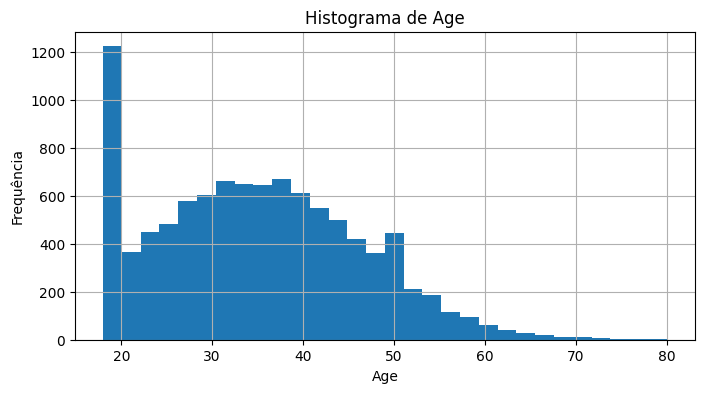

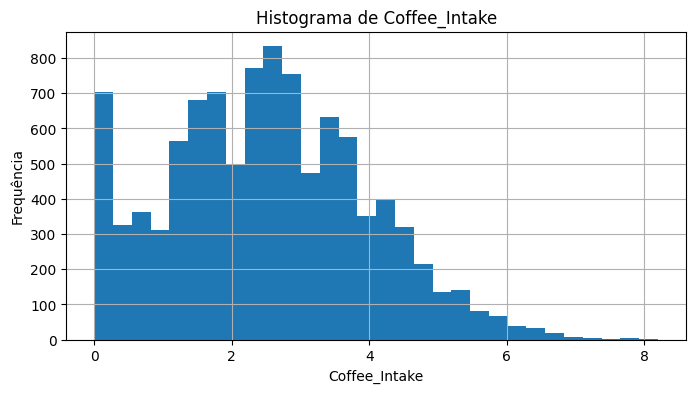

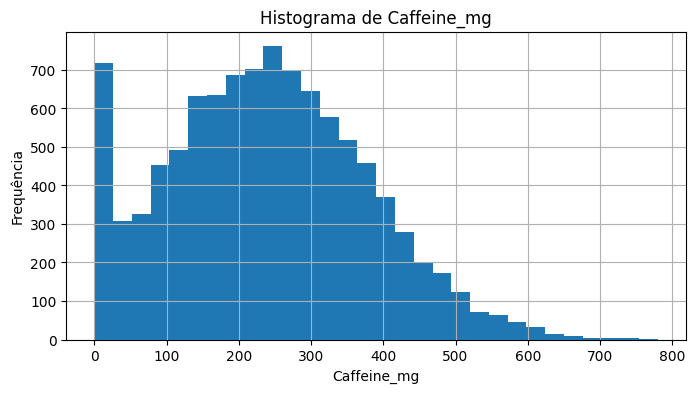

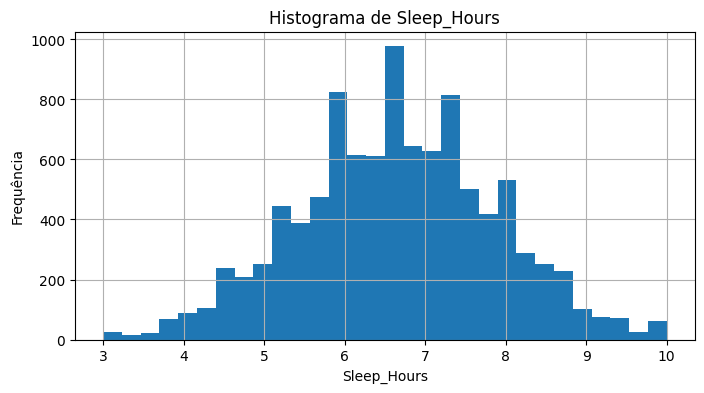

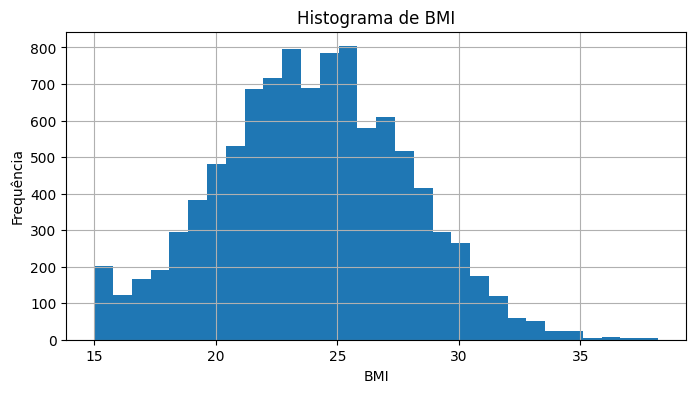

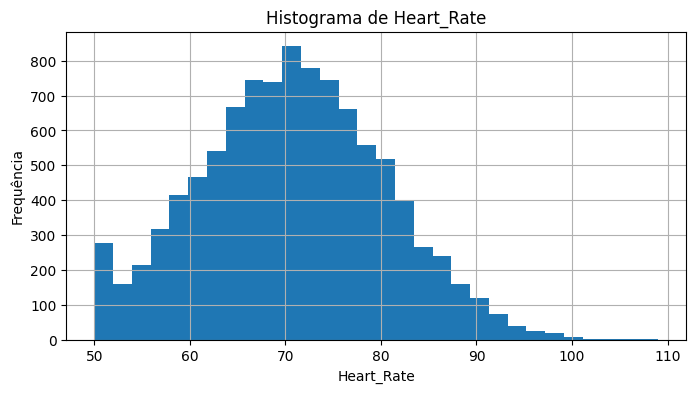

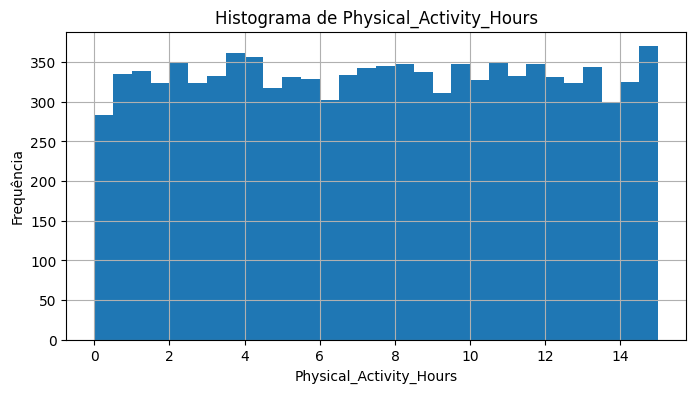

In [8]:
# Histogramas para columnas numéricas
for col in col_numericas:
    plt.figure(figsize=(8, 4))
    df[col].hist(bins=30)
    plt.title(f'Histograma de {col}')
    plt.xlabel(col)
    plt.ylabel('Frequência')
    plt.show()

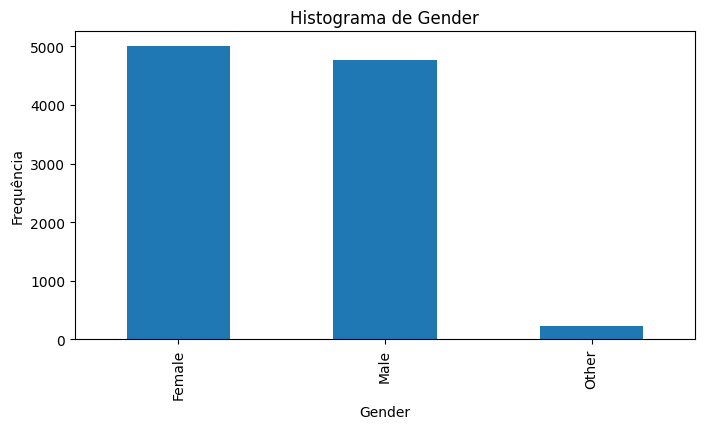

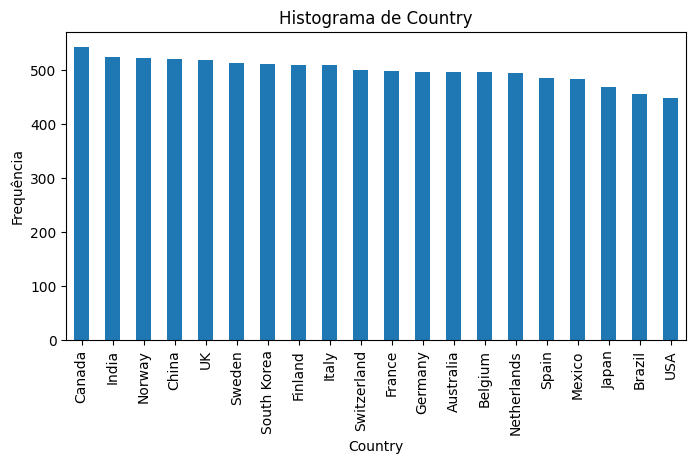

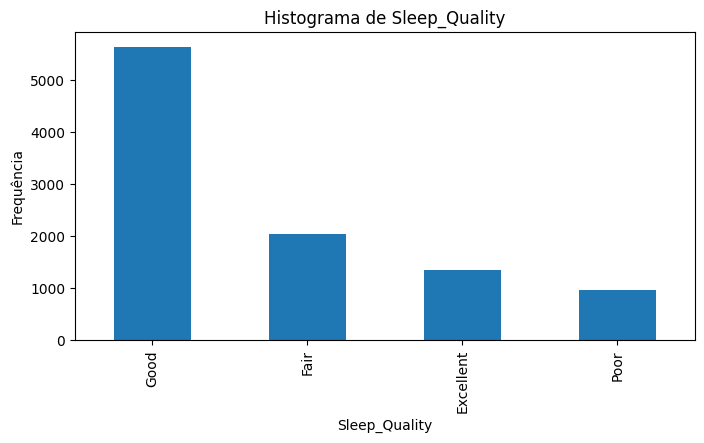

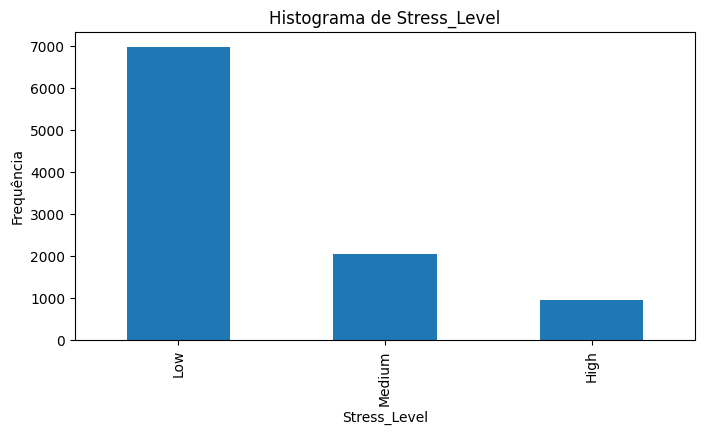

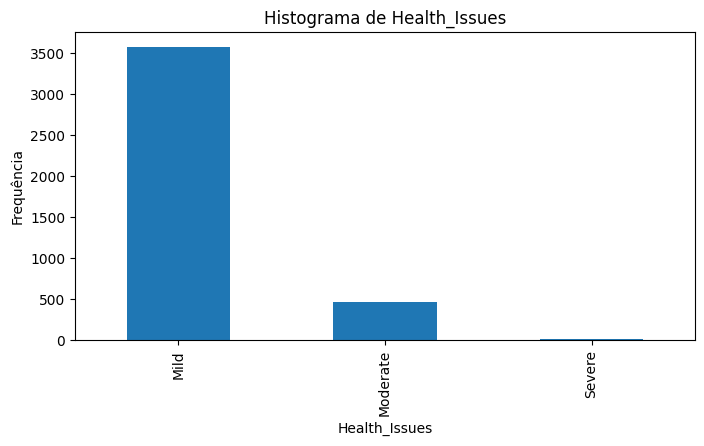

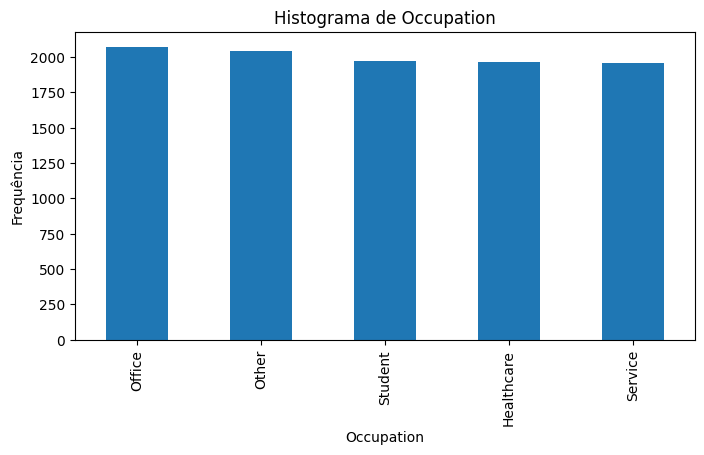

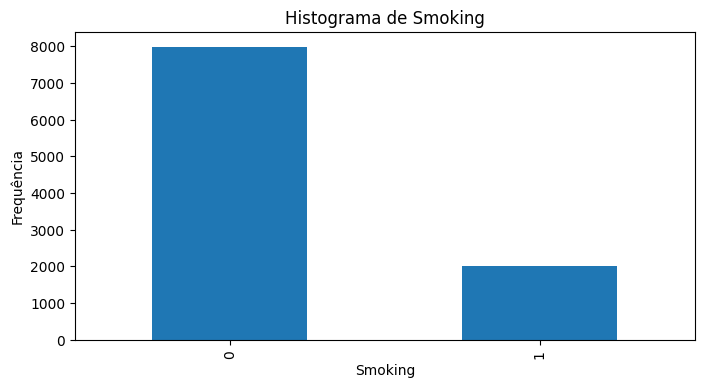

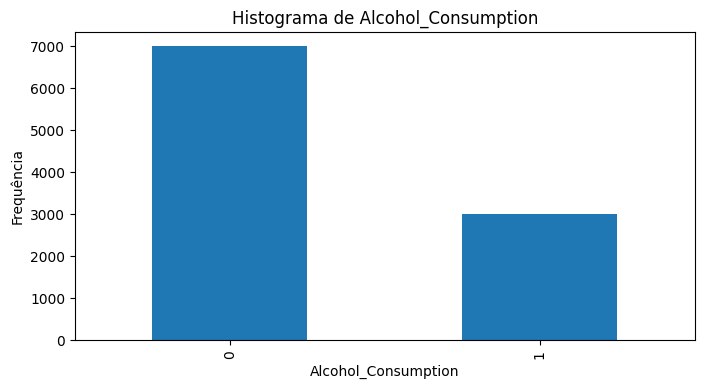

In [9]:
# Histograma para columnas categóricas
for col in col_categoricas:
    plt.figure(figsize=(8, 4))
    df[col].value_counts().plot(kind='bar')
    plt.title(f'Histograma de {col}')
    plt.xlabel(col)
    plt.ylabel('Frequência')
    plt.show()

Analizando los histogramas de las variables categóricas podemos percatarnos de que las variables categóricas no están balanceadas, en específico es de relevancia ya que la variable objetivo es el nivel de estrés y tiene muy pocos registros de personas con altos niveles de estrés, por lo que se tendrán que balanacear las clases con diferentes estrategias ya sea SMOTE para que este desbalance no afecte el desempeño del modelo.

Esto se hará también para la calidad de sueño, si la persona fuma o no y si consume alcohol.

### Cálculo de sesgo
---

In [10]:
skewness = pd.DataFrame(columns=["valor"])

for column in col_numericas:
    skew_valor = round(df[column].skew(), 2)  
    skewness.loc[column] = skew_valor  

skewness = skewness.rename(columns={0: "valor"})

def sesgo(x):
    if x['valor'] < -1 or x['valor'] > 1:
        return 'altamente sesgada'
    elif (x['valor'] <= 0 and x['valor'] >= -0.5) or (x['valor'] >= 0 and x['valor'] <= 0.5):
        return 'distribución simetrica'
    else:
        return 'sesgo moderado'

skewness['sesgo'] = skewness.apply(sesgo, axis=1)

print(skewness)

                         valor                   sesgo
Age                       0.36  distribución simetrica
Coffee_Intake             0.26  distribución simetrica
Caffeine_mg               0.26  distribución simetrica
Sleep_Hours              -0.02  distribución simetrica
BMI                       0.05  distribución simetrica
Heart_Rate                0.10  distribución simetrica
Physical_Activity_Hours   0.00  distribución simetrica


Analizando los histogramas y el sesgo de las variables numéricas, podemos ver que las variables siguen una distirbución, por lo que no será necesario aplicar ninguna transformación.

### Diagramas de Cajas y Bigotes
---

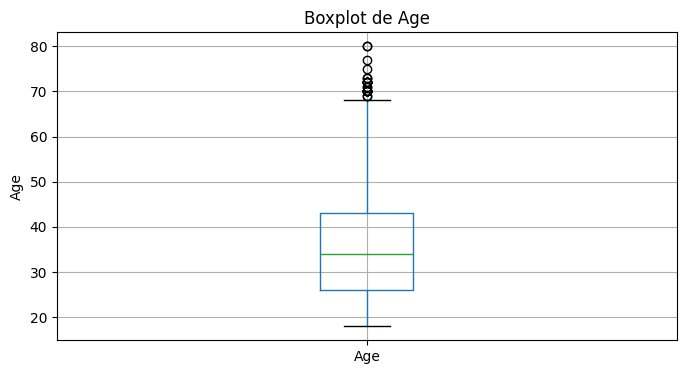

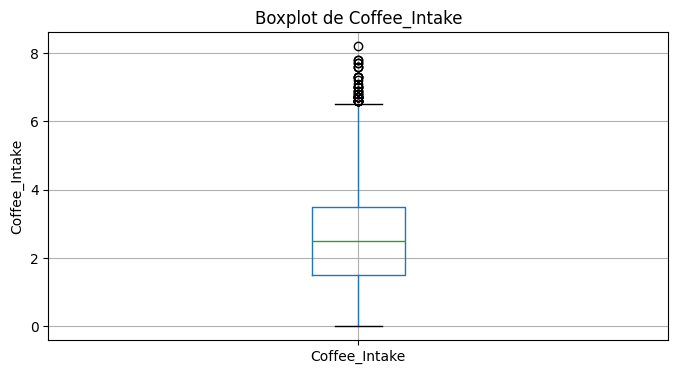

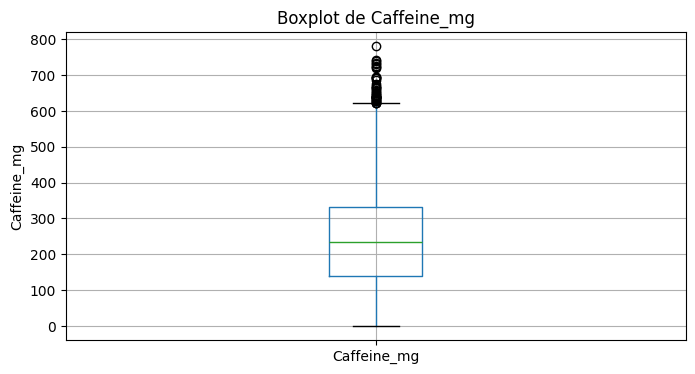

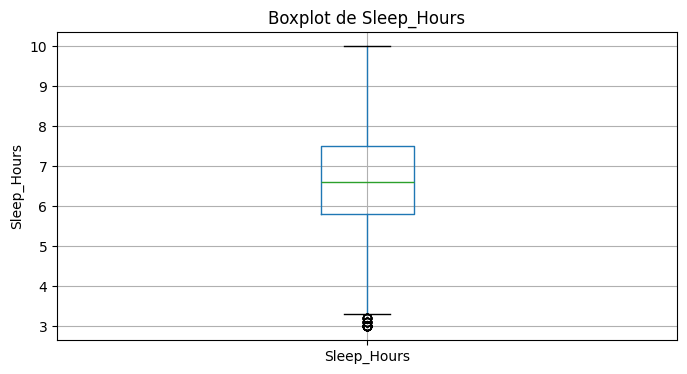

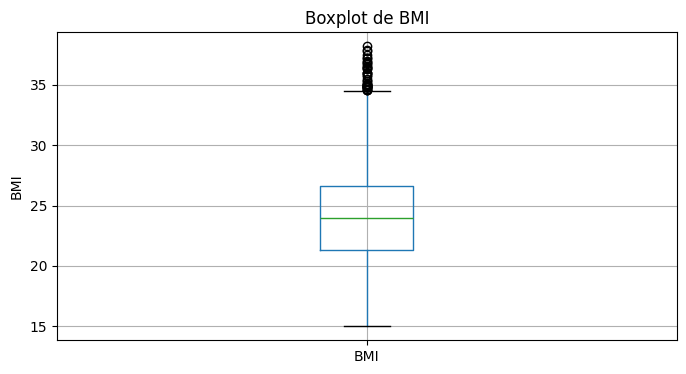

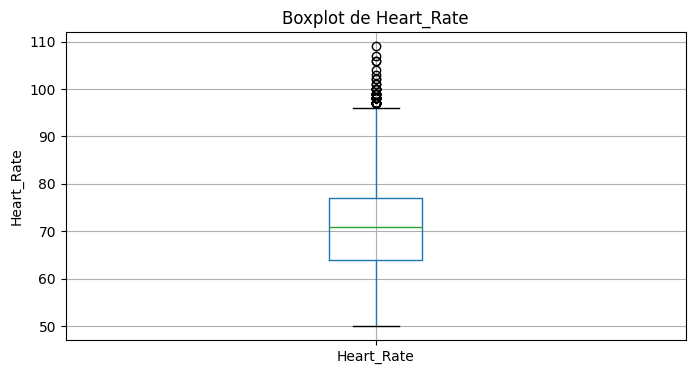

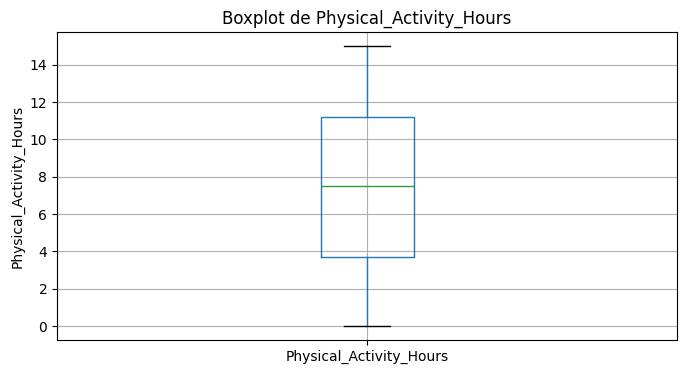

In [11]:
# Boxplot para visualizar outliers
for col in col_numericas:
    plt.figure(figsize=(8, 4))
    df.boxplot(column=col)
    plt.title(f'Boxplot de {col}')
    plt.ylabel(col)
    plt.show()

Con estas gráficas podemos confirmar y mostrar de manera más visible los valores atípicos que habíamos visto anteriormente que tenían las variables numéricas, sin embargo como ya habíamos mencionado previamente, al no superar el 0.05% de los datos, no se les dará un tratamiento y se dejarán así.

### Matriz de correlación
---

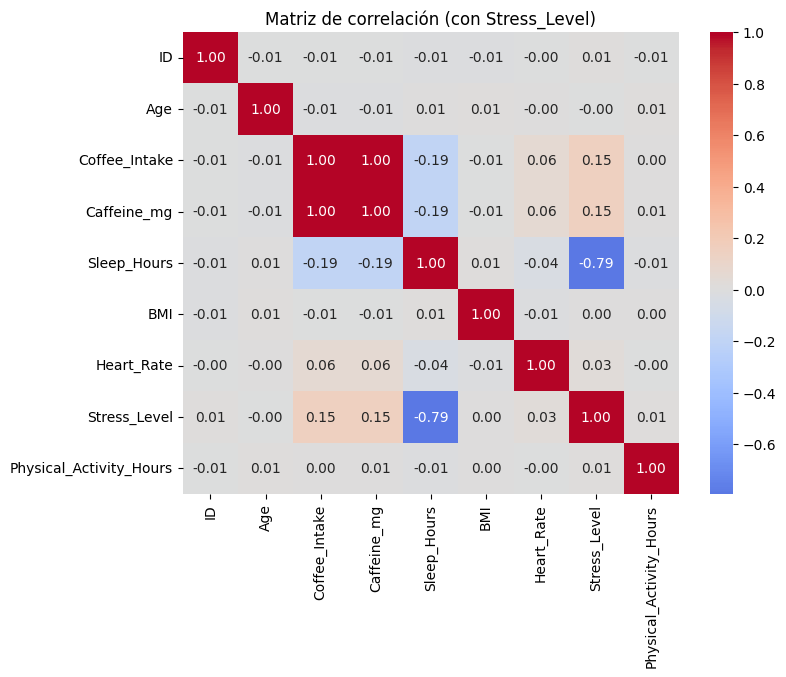

In [12]:
df['Stress_Level'] = df['Stress_Level'].map({'Low': 0, 'Medium': 1, 'High': 2})
df['Stress_Level'] = df['Stress_Level'].astype(float)

# Calcular matriz de correlación completa
corr_matrix = df.corr(numeric_only=True)
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, annot=True, fmt=".2f")
plt.title("Matriz de correlación (con Stress_Level)")
plt.show()

In [14]:
df['Gender'].value_counts()

Gender
Female    5001
Male      4773
Other      226
Name: count, dtype: int64

Como podemos observar en la matriz de correlación, las variables de **Coffe_Intake** y **Caffeine_mg** están altamente correlacionadas, lo cual tiene sentido ya que el consumo de cafeína se obtiene a partir del consumo del café, por lo que más adelante se removerá el consumo de cafeína para evitar la multicolinealidad y que esto no afecte el desemepño del modelo

### Conclusiones preliminares
---

***Valores faltantes***

Al ser la variable de **Health_Issues** la única con datos nulos, superando el 50% se eliminará la variable y no se trabajará con ella para el modelado.

***Valores duplicados***

Al no haber valores duplicados en ninguna de las variables no se tendrá que hacer ningún preprocesamiento en específico.

***Valores atípicos***

Al ser el 0.05% del total de los datos con los que se está trabajando, no se eliminarán ni se tratarán estos outliers.

***Distribuciones***
.
Para las variables numéricas al comprobar con los histogramas y el cálculo del sesgo que las variables siguen una distribución normal, no será necesario aplicar ninguna transformación.

Para las variables categóricas se identificó que las clases no están balanceadas por lo que se usará el método de SMOTE para balancear las clases de la variable objetivo, en este caso el nivel de estrés, esto es esencial ya que la variable a predecir está desbalanceada por lo que si no se trata el desbalance, el rendimiento del modelo se verá perjudicado.

***Correlaciones***

Al analizar la matriz de correlación entre las variables predictoras, podemos observar que existe una muy alta correlación entre **Caffeine_Intake** y **Caffeine_mg**, así que se optará por eliminar la variable **Caffeine_mg** ya que ésta se obtiene a partir del consumo de café. 

Así mismo, se eliminarán las variables que tienen alta correlación con la variable objetivo para evitar el data leakage, como lo son **Sleep_Hours** y **Sleep_Quality**.